In [1]:

import numpy as np
import matplotlib.pyplot as plt
import random as rn
import importlib
from scipy.spatial import KDTree

# Import Customized python classes
import sys
import os
target_dir = os.path.dirname('/home/kestrel1311/git/src/Defender_Strategy/script/')
if target_dir not in sys.path:
    sys.path.append(target_dir)
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera
import Dynamic
import convex_map

importlib.reload(Dynamic)
from Dynamic import DynamicMap

- RRT* with dubins' path as segment
  - What's different from normal RRT* with dubins'?
    - Dubins' path must be collision-free
    - Rewiring step takes modified cost function: $J = w_{det,omni}*C_{det,omni} + w_{det,direc}*C_{det,direc} + w_{dist}*C_{dist}$
      - $C_{det}$: Detection cost by omnidirectional / directional sensors
      - $C_{dist}$: Distance cost from the best neighbor
    - Assume constant velocity along dubins' path segment

In [2]:
map_size = (50, 50)
num_buildings = 3
num_direc_sensor = 0
num_omni_sensor = 0
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(15)
max_range = 20
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
# rng_seed = rn.randint(1, 1000)
rng_seed = 2
# rng_seed = 2
print(rng_seed)

2


(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot: title={'center': 'Operation Map @ t = 0.00'}>)

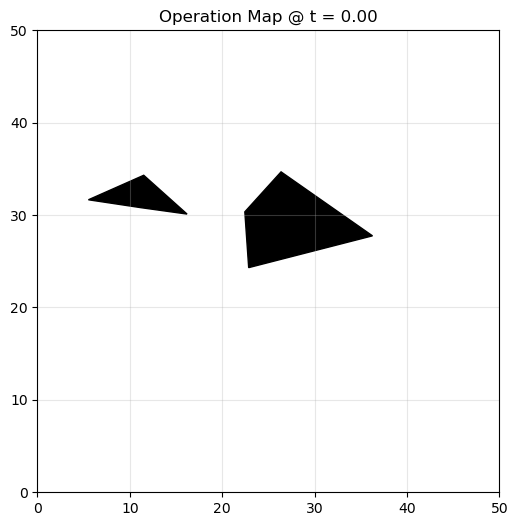

In [3]:
# Generate map
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

# Parse map_in dictionary
map_size = map_in['st']['size']

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [4]:
# Setup for Attacker Strategy: STP-RRT*
pos_start = [0, 0]
pos_goal = [50, 50]
psi_start = np.deg2rad(0)
psi_goal = np.deg2rad(90)
t_start = 0

x0 = [pos_start[0], pos_start[1], psi_start, t_start]
xf = [pos_goal[0], pos_goal[1], psi_goal]

# Generate Dynamic Map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# Vehicle Spec
vehicle = {}
vehicle['radius'] = 1

In [5]:
# Pre-compute Bounding Box
obstacles = {}
obstacles['bbox_min'] = []
obstacles['bbox_max'] = []
obstacles['edges'] = []
for i in range(map_in['st']['n']):
    OBSTACLE_VERTS = map_in['st'][str(i)]
    BBOX_MIN = np.min(OBSTACLE_VERTS, axis=0)
    BBOX_MAX = np.max(OBSTACLE_VERTS, axis=0)
    
    # Pre-compute edge vectors and p1 points for the Half-Plane test
    EDGES = np.roll(OBSTACLE_VERTS, -1, axis=0) - OBSTACLE_VERTS

    obstacles['bbox_min'].append(BBOX_MIN)
    obstacles['bbox_max'].append(BBOX_MAX)
    obstacles['edges'].append(EDGES)

In [6]:
def distance(a, b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2 )

In [7]:
# Physical Constants
g = 9.81 

# Speed (m/s)
v_modes = {1: 7.0, 2: 11.0, 3: 15.0}

# Realistic Bank Angles for Sport Cub S2
bank_angles = {1: 25.0, 2: 35.0, 3: 45.0}

# Derived Turning Radius: R = v^2 / (g * tan(phi))
turn_radius_modes = {
    m: (v_modes[m]**2) / (g * np.tan(np.radians(bank_angles[m])))
    for m in [1, 2, 3]
}

# Acoustic Noise (n): Modeled as proportional to v^3
# We normalize it so Mode 1 = 1.0 units of noise
n_modes = {
    m: (v_modes[m] / v_modes[1])**3 
    for m in [1, 2, 3]
}

# Guard Conditions
r_mode1 = 30.0
r_mode3 = r_mode1*1.75

hybrid_model_UAV = {}
hybrid_model_UAV['v'] = v_modes
hybrid_model_UAV['noise'] = n_modes
hybrid_model_UAV['r_turn'] = turn_radius_modes
hybrid_model_UAV['guard_condition'] = [r_mode1, r_mode3]

# Results:
print('Speed: ', v_modes)
print('Turn radius: ', turn_radius_modes)
print('Noise Level: ', n_modes)

Speed:  {1: 7.0, 2: 11.0, 3: 15.0}
Turn radius:  {1: 10.711604393982505, 2: 17.61528122485177, 3: 22.935779816513765}
Noise Level:  {1: 1.0, 2: 3.880466472303207, 3: 9.839650145772595}


In [8]:
def mode_selection(X, hybrid_model, cameras):
    # X: starting point
    x = X[0]
    y = X[1]
    psi = X[2]
    
    r_mode1, r_mode3 = hybrid_model['guard_condition']
    
    if cameras['n'] > 0:
        sensor_pos = []
        for si in range(cameras['n']):
            if si < cameras['n_direc']:
                sensor_pos.append([cameras['directional']['x'], cameras['directional']['y']])
            else:
                sensor_pos.append([cameras['omnidirectional']['x'], cameras['omnidirectional']['y']])
            
        dist_vec = []
        for sj in range(cameras['n']):
            dist_vec.append(distance([x, y], sensor_pos[sj]))

        if any(dist_vec[sj] < r_mode1 for sj in range(cameras['n'])):
            mode = 1
        elif all(dist_vec[sj] > r_mode3 for sj in range(cameras['n'])):
            mode = 3
        else:
            mode = 2
    else:
        # In no-sensor test, nominal speed
        mode = 2
        
    return mode

In [9]:
def _mod2pi(a: float) -> float:
    return (a % (2.0*np.pi))

def _sample_arc(center, ang0, delta, turn, n):
    """
    center: (2,)
    ang0  : angle(center -> start point)
    delta : positive arc angle magnitude (rad)
    turn  : 'R' (clockwise) or 'L' (ccw)
    n     : number of samples (>=2)
    returns: (n,3) [x,y,theta]
    """
    center = np.asarray(center, dtype=float)

    if n <= 1:
        n = 2

    s = np.linspace(0.0, delta, n)
    if turn.upper() == 'R':
        ang = ang0 - s                 # clockwise
        theta = ang - 0.5*np.pi        # heading tangent to circle (CW)
    else:
        ang = ang0 + s                 # ccw
        theta = ang + 0.5*np.pi        # heading tangent to circle (CCW)

    xy = center[None, :] + np.column_stack([np.cos(ang), np.sin(ang)])
    out = np.column_stack([xy, _mod2pi(theta)])
    return out

def _sample_straight(p_from, p_to, n):
    """
    returns: (n,3) [x,y,theta]
    """
    p_from = np.asarray(p_from, dtype=float)
    p_to   = np.asarray(p_to, dtype=float)

    if n <= 1:
        n = 2

    t = np.linspace(0.0, 1.0, n)
    xy = (1.0 - t)[:, None]*p_from[None, :] + t[:, None]*p_to[None, :]
    th = np.arctan2(p_to[1]-p_from[1], p_to[0]-p_from[0])
    out = np.column_stack([xy, np.full((n,), _mod2pi(th))])
    return out

def _rescale_arc_points(arc, center, r, turn):
    center = np.asarray(center, dtype=float)
    ang = np.arctan2(arc[:,1] - center[1], arc[:,0] - center[0])
    xy = center[None, :] + r*np.column_stack([np.cos(ang), np.sin(ang)])
    if turn.upper() == 'R':
        th = _mod2pi(ang - 0.5*np.pi)
    else:
        th = _mod2pi(ang + 0.5*np.pi)
    return np.column_stack([xy, th])

def rsl(X1, X2, r, N=100):
    """
    Dubins RSL (Right arc, Straight, Left arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('RSL', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)

    p1, theta1 = X1[0:2], float(X1[2])
    p2, theta2 = X2[0:2], float(X2[2])
    r = float(r)

    # Turning circle centers
    # Right-turn center is to the right of heading: +r*[sin(th), -cos(th)]
    c1 = p1 + r*np.array([np.sin(theta1), -np.cos(theta1)])
    # Left-turn center is to the left of heading: +r*[-sin(th), +cos(th)]
    c2 = p2 + r*np.array([-np.sin(theta2),  np.cos(theta2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # RSL uses the internal tangent between opposite-turn circles (requires d >= 2r)
    if d < 2.0*r:
        return 'RSL', None, np.inf

    v = dvec / d
    perp = np.array([-v[1], v[0]])

    # internal tangent geometry (treat r2 = -r)
    phi = np.arccos((2.0*r)/d)  # in [0, pi/2]
    # Two possible internal tangents: +/- phi
    candidates = []
    for sgn in (+1.0, -1.0):
        u = v*np.cos(phi) + perp*(sgn*np.sin(phi))  # unit direction from c1 to tangent point on circle1
        t1 = c1 + r*u
        t2 = c2 - r*u

        # Angles from centers to relevant points
        ang_p1 = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
        ang_t1 = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])

        ang_t2 = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
        ang_p2 = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])

        # Right arc: clockwise from p1 to t1
        dR = _mod2pi(ang_p1 - ang_t1)
        # Left arc: ccw from t2 to p2
        dL = _mod2pi(ang_p2 - ang_t2)

        L1 = r * dR
        L2 = float(np.hypot(t2[0]-t1[0], t2[1]-t1[1]))
        L3 = r * dL
        Ltot = L1 + L2 + L3

        candidates.append((Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2))

    # pick shortest feasible of the two tangents
    Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2 = min(candidates, key=lambda x: x[0])

    # Sampling allocation (ensure each segment has at least 2 points)
    if not np.isfinite(Ltot) or Ltot <= 0:
        return 'RSL', None, np.inf

    # Proportional split, with guards
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    # If rounding made n3 too small, fix by stealing from the longest segment
    while n1 + n2 + n3 < N:
        # add to straight by default
        n2 += 1
    while n1 + n2 + n3 > N:
        # remove from the largest n among (n1,n2,n3) but keep >=2
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build sampled path (avoid duplicate join points by dropping the first point of later segments)
    arc1 = _sample_arc(c1, ang_p1, _mod2pi(ang_p1 - ang_t1), 'R', n1)
    straight = _sample_straight(t1, t2, n2)[1:, :]
    arc3 = _sample_arc(c2, ang_t2, _mod2pi(ang_p2 - ang_t2), 'L', n3)[1:, :]

    # Fix radii in arc sampler: it currently uses unit radius; scale positions by r about center
    # (Implemented by rewriting arc sampler output here for clarity.)
    def _rescale_arc_points(arc, center, r, turn):
        center = np.asarray(center, dtype=float)
        # Recover angles from positions (unit circle output)
        # arc[:,0:2] = center + [cos ang, sin ang]
        ang = np.arctan2(arc[:,1] - center[1], arc[:,0] - center[0])
        xy = center[None, :] + r*np.column_stack([np.cos(ang), np.sin(ang)])
        if turn.upper() == 'R':
            th = _mod2pi(ang - 0.5*np.pi)
        else:
            th = _mod2pi(ang + 0.5*np.pi)
        return np.column_stack([xy, th])

    arc1 = _rescale_arc_points(arc1, c1, r, 'R')
    arc3 = _rescale_arc_points(arc3, c2, r, 'L')

    full_path = np.vstack([arc1, straight, arc3])
    return 'RSL', full_path, Ltot

def lsr(X1, X2, r, N=100):
    """
    Dubins LSR (Left arc, Straight, Right arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('LSR', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)

    p1, theta1 = X1[0:2], float(X1[2])
    p2, theta2 = X2[0:2], float(X2[2])
    r = float(r)

    # Turning circle centers
    # Left-turn center: +r*[-sin(th), +cos(th)]
    c1 = p1 + r*np.array([-np.sin(theta1),  np.cos(theta1)])
    # Right-turn center: +r*[sin(th), -cos(th)]
    c2 = p2 + r*np.array([ np.sin(theta2), -np.cos(theta2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # LSR uses the internal tangent between opposite-turn circles (requires d >= 2r)
    if d < 2.0*r:
        return 'LSR', None, np.inf

    v = dvec / d
    perp = np.array([-v[1], v[0]])

    # internal tangent geometry (r2 = -r)
    phi = np.arccos((2.0*r)/d)
    candidates = []
    for sgn in (+1.0, -1.0):
        u = v*np.cos(phi) + perp*(sgn*np.sin(phi))  # unit direction from c1 to tangent point on circle1
        t1 = c1 + r*u
        t2 = c2 - r*u

        # Angles from centers
        ang_p1 = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
        ang_t1 = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])

        ang_t2 = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
        ang_p2 = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])

        # Left arc: ccw from p1 to t1
        dL = _mod2pi(ang_t1 - ang_p1)
        # Right arc: clockwise from t2 to p2
        dR = _mod2pi(ang_t2 - ang_p2)

        L1 = r * dL
        L2 = float(np.hypot(t2[0]-t1[0], t2[1]-t1[1]))
        L3 = r * dR
        Ltot = L1 + L2 + L3

        candidates.append((Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2))

    Ltot, L1, L2, L3, t1, t2, ang_p1, ang_t1, ang_t2, ang_p2 = min(candidates, key=lambda x: x[0])

    if not np.isfinite(Ltot) or Ltot <= 0:
        return 'LSR', None, np.inf

    # Sampling allocation
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    while n1 + n2 + n3 < N:
        n2 += 1
    while n1 + n2 + n3 > N:
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build path (drop duplicate join points)
    arc1 = _sample_arc(c1, ang_p1, _mod2pi(ang_t1 - ang_p1), 'L', n1)
    straight = _sample_straight(t1, t2, n2)[1:, :]
    arc3 = _sample_arc(c2, ang_t2, _mod2pi(ang_t2 - ang_p2), 'R', n3)[1:, :]

    # rescale arcs to radius r
    arc1 = _rescale_arc_points(arc1, c1, r, 'L')
    arc3 = _rescale_arc_points(arc3, c2, r, 'R')

    full_path = np.vstack([arc1, straight, arc3])
    return 'LSR', full_path, Ltot

def rlr(X1, X2, r, N=100):
    """
    Dubins RLR (Right arc, Left arc, Right arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('RLR', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)
    p1, th1 = X1[0:2], float(X1[2])
    p2, th2 = X2[0:2], float(X2[2])
    r = float(r)

    # Right-turn circle centers at start and end
    c1 = p1 + r*np.array([np.sin(th1), -np.cos(th1)])
    c2 = p2 + r*np.array([np.sin(th2), -np.cos(th2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # For RLR, the intermediate (left) circle center must be at distance 2r from BOTH c1 and c2
    # => intersection of circles radius 2r around c1 and c2 exists only if d <= 4r
    if d > 4.0*r or d < 1e-12:
        return 'RLR', None, np.inf

    R = 2.0*r
    v = dvec / d
    perp = np.array([-v[1], v[0]])
    mid = 0.5*(c1 + c2)

    # circle-circle intersection (equal radii)
    a = 0.5*d
    h2 = R*R - a*a
    if h2 < 0.0:
        return 'RLR', None, np.inf
    h = float(np.sqrt(max(0.0, h2)))

    cM_candidates = [mid + h*perp, mid - h*perp]

    best = None
    for cM in cM_candidates:
        cM = np.asarray(cM, dtype=float)

        # Switch points are the external tangency points between circles whose centers are 2r apart
        u12 = (cM - c1) / np.linalg.norm(cM - c1)   # |cM-c1| = 2r
        u23 = (cM - c2) / np.linalg.norm(cM - c2)   # |cM-c2| = 2r

        s12 = c1 + r*u12     # point on start right circle and middle left circle
        s23 = c2 + r*u23     # point on end right circle and middle left circle

        # Angles (center -> point)
        ang_p1_c1  = np.arctan2(p1[1]-c1[1],  p1[0]-c1[0])
        ang_s12_c1 = np.arctan2(s12[1]-c1[1], s12[0]-c1[0])

        ang_s12_cM = np.arctan2(s12[1]-cM[1], s12[0]-cM[0])
        ang_s23_cM = np.arctan2(s23[1]-cM[1], s23[0]-cM[0])

        ang_s23_c2 = np.arctan2(s23[1]-c2[1], s23[0]-c2[0])
        ang_p2_c2  = np.arctan2(p2[1]-c2[1],  p2[0]-c2[0])

        # Arc angles
        dR1 = _mod2pi(ang_p1_c1 - ang_s12_c1)        # Right: clockwise p1 -> s12
        dL  = _mod2pi(ang_s23_cM - ang_s12_cM)       # Left : ccw      s12 -> s23
        dR2 = _mod2pi(ang_s23_c2 - ang_p2_c2)        # Right: clockwise s23 -> p2

        L1, L2, L3 = r*dR1, r*dL, r*dR2
        Ltot = L1 + L2 + L3

        cand = (Ltot, L1, L2, L3, cM, ang_p1_c1, dR1, ang_s12_cM, dL, ang_s23_c2, dR2, c1, c2)
        if best is None or cand[0] < best[0]:
            best = cand

    if best is None or not np.isfinite(best[0]) or best[0] <= 0.0:
        return 'RLR', None, np.inf

    Ltot, L1, L2, L3, cM, ang_p1_c1, dR1, ang_s12_cM, dL, ang_s23_c2, dR2, c1, c2 = best

    # Sampling allocation across 3 arcs
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    while n1 + n2 + n3 < N:
        n2 += 1
    while n1 + n2 + n3 > N:
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build path (drop duplicate join points)
    arc1_u = _sample_arc(c1, ang_p1_c1, dR1, 'R', n1)
    arc2_u = _sample_arc(cM, ang_s12_cM, dL,  'L', n2)[1:, :]
    arc3_u = _sample_arc(c2, ang_s23_c2, dR2, 'R', n3)[1:, :]

    arc1 = _rescale_arc_points(arc1_u, c1, r, 'R')
    arc2 = _rescale_arc_points(arc2_u, cM, r, 'L')
    arc3 = _rescale_arc_points(arc3_u, c2, r, 'R')

    full_path = np.vstack([arc1, arc2, arc3])
    return 'RLR', full_path, Ltot

def lrl(X1, X2, r, N=100):
    """
    Dubins LRL (Left arc, Right arc, Left arc)
    X1, X2: [x, y, theta] (theta in rad)
    r     : turning radius
    N     : total samples along the full path

    returns: ('LRL', full_path (Nx3), total_length)
    """
    X1 = np.asarray(X1, dtype=float).reshape(3,)
    X2 = np.asarray(X2, dtype=float).reshape(3,)
    p1, th1 = X1[0:2], float(X1[2])
    p2, th2 = X2[0:2], float(X2[2])
    r = float(r)

    # Left-turn circle centers at start and end
    c1 = p1 + r*np.array([-np.sin(th1),  np.cos(th1)])
    c2 = p2 + r*np.array([-np.sin(th2),  np.cos(th2)])

    dvec = c2 - c1
    d = float(np.hypot(dvec[0], dvec[1]))

    # For LRL, the intermediate (right) circle center must be at distance 2r from BOTH c1 and c2
    # => intersection of circles radius 2r around c1 and c2 exists only if d <= 4r
    if d > 4.0*r or d < 1e-12:
        return 'LRL', None, np.inf

    R = 2.0*r
    v = dvec / d
    perp = np.array([-v[1], v[0]])
    mid = 0.5*(c1 + c2)

    # circle-circle intersection (equal radii)
    a = 0.5*d
    h2 = R*R - a*a
    if h2 < 0.0:
        return 'LRL', None, np.inf
    h = float(np.sqrt(max(0.0, h2)))

    cM_candidates = [mid + h*perp, mid - h*perp]

    best = None
    for cM in cM_candidates:
        cM = np.asarray(cM, dtype=float)

        # Switch points are the external tangency points between circles whose centers are 2r apart
        u12 = (cM - c1) / np.linalg.norm(cM - c1)   # |cM-c1| = 2r
        u23 = (cM - c2) / np.linalg.norm(cM - c2)   # |cM-c2| = 2r

        s12 = c1 + r*u12     # point on start left circle and middle right circle
        s23 = c2 + r*u23     # point on end left circle and middle right circle

        # Angles (center -> point)
        ang_p1_c1  = np.arctan2(p1[1]-c1[1],  p1[0]-c1[0])
        ang_s12_c1 = np.arctan2(s12[1]-c1[1], s12[0]-c1[0])

        ang_s12_cM = np.arctan2(s12[1]-cM[1], s12[0]-cM[0])
        ang_s23_cM = np.arctan2(s23[1]-cM[1], s23[0]-cM[0])

        ang_s23_c2 = np.arctan2(s23[1]-c2[1], s23[0]-c2[0])
        ang_p2_c2  = np.arctan2(p2[1]-c2[1],  p2[0]-c2[0])

        # Arc angles
        dL1 = _mod2pi(ang_s12_c1 - ang_p1_c1)        # Left : ccw      p1 -> s12
        dR  = _mod2pi(ang_s12_cM - ang_s23_cM)       # Right: clockwise s12 -> s23
        dL2 = _mod2pi(ang_p2_c2 - ang_s23_c2)        # Left : ccw      s23 -> p2

        L1, L2, L3 = r*dL1, r*dR, r*dL2
        Ltot = L1 + L2 + L3

        cand = (Ltot, L1, L2, L3, cM, ang_p1_c1, dL1, ang_s12_cM, dR, ang_s23_c2, dL2, c1, c2)
        if best is None or cand[0] < best[0]:
            best = cand

    if best is None or not np.isfinite(best[0]) or best[0] <= 0.0:
        return 'LRL', None, np.inf

    Ltot, L1, L2, L3, cM, ang_p1_c1, dL1, ang_s12_cM, dR, ang_s23_c2, dL2, c1, c2 = best

    # Sampling allocation across 3 arcs
    n1 = max(2, int(round(N * (L1 / Ltot))))
    n2 = max(2, int(round(N * (L2 / Ltot))))
    n3 = max(2, N - n1 - n2)
    while n1 + n2 + n3 < N:
        n2 += 1
    while n1 + n2 + n3 > N:
        idx = int(np.argmax([n1, n2, n3]))
        if idx == 0 and n1 > 2: n1 -= 1
        elif idx == 1 and n2 > 2: n2 -= 1
        elif idx == 2 and n3 > 2: n3 -= 1
        else:
            break

    # Build path (drop duplicate join points)
    arc1_u = _sample_arc(c1, ang_p1_c1, dL1, 'L', n1)
    arc2_u = _sample_arc(cM, ang_s12_cM, dR,  'R', n2)[1:, :]
    arc3_u = _sample_arc(c2, ang_s23_c2, dL2, 'L', n3)[1:, :]

    arc1 = _rescale_arc_points(arc1_u, c1, r, 'L')
    arc2 = _rescale_arc_points(arc2_u, cM, r, 'R')
    arc3 = _rescale_arc_points(arc3_u, c2, r, 'L')

    full_path = np.vstack([arc1, arc2, arc3])
    return 'LRL', full_path, Ltot

In [10]:
def rsr(X1, X2, r, N=100):
    p1, theta1 = X1[0:2], X1[2]
    p2, theta2 = X2[0:2], X2[2]
    
    # 1. Centers for Right-turn (CW)
    # Right turn center is at -90 degrees from heading
    c1 = p1 + np.array([r*np.sin(theta1), -r*np.cos(theta1)])
    c2 = p2 + np.array([r*np.sin(theta2), -r*np.cos(theta2)])
    
    v = c2 - c1
    L_straight = np.linalg.norm(v)
    
    # 2. Straight Segment Heading (The Anchor)
    # For RSR, the straight line is parallel to the vector between centers
    theta_straight = np.arctan2(v[1], v[0])
    
    # 3. Tangent Points
    # Tangent is at -90 deg from center-to-center vector for RSR
    t1 = c1 + np.array([r*np.cos(theta_straight + np.pi/2), 
                        r*np.sin(theta_straight + np.pi/2)])
    t2 = c2 + np.array([r*np.cos(theta_straight + np.pi/2), 
                        r*np.sin(theta_straight + np.pi/2)])
    
    # 4. Arc 1 Interpolation
    alpha_start = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
    alpha_end = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])
    
    # Clockwise distance
    diff1 = (alpha_start - alpha_end) % (2 * np.pi)
    angles1 = alpha_start - np.linspace(0, diff1, N // 3)
    
    arc1_pos = np.stack([c1[0] + r*np.cos(angles1), c1[1] + r*np.sin(angles1)], axis=1)
    # Heading is angle of radius - 90 deg for CW
    arc1_heads = angles1 - np.pi/2

    # 5. Straight Interpolation
    straight_pos = np.linspace(t1, t2, N // 3)
    straight_heads = np.full(N // 3, theta_straight)

    # 6. Arc 2 Interpolation
    beta_start = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
    beta_end = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])
    
    diff2 = (beta_start - beta_end) % (2 * np.pi)
    angles2 = beta_start - np.linspace(0, diff2, N // 3)
    
    arc2_pos = np.stack([c2[0] + r*np.cos(angles2), c2[1] + r*np.sin(angles2)], axis=1)
    arc2_heads = angles2 - np.pi/2

    # 7. Final Assembly with Clean Normalization
    all_pos = np.vstack([arc1_pos, straight_pos, arc2_pos])
    all_heads = np.concatenate([arc1_heads, straight_heads, arc2_heads])
    
    # Normalize headings to [-pi, pi] and ensure no 180-degree flips
    final_heads = np.arctan2(np.sin(all_heads), np.cos(all_heads))
    
    full_path = np.column_stack([all_pos, final_heads])
    total_length = r*diff1 + L_straight + r*diff2
    
    return 'RSR', full_path, total_length

In [11]:
def lsl(X1, X2, r, N=100):
    p1, theta1 = X1[0:2], X1[2]
    p2, theta2 = X2[0:2], X2[2]
    
    # 1. Centers for Right-turn (CW)
    # Left turn center is at +90 degrees from heading
    c1 = p1 + np.array([-r*np.sin(theta1), r*np.cos(theta1)])
    c2 = p2 + np.array([-r*np.sin(theta2), r*np.cos(theta2)])
    
    v = c2 - c1
    L_straight = np.linalg.norm(v)
    
    # 2. Straight Segment Heading (The Anchor)
    # For RSR, the straight line is parallel to the vector between centers
    theta_straight = np.arctan2(v[1], v[0])
    
    # 3. Tangent Points
    # Tangent is at -90 deg from center-to-center vector for LSL
    t1 = c1 + np.array([r*np.cos(theta_straight - np.pi/2), 
                        r*np.sin(theta_straight - np.pi/2)])
    t2 = c2 + np.array([r*np.cos(theta_straight - np.pi/2), 
                        r*np.sin(theta_straight - np.pi/2)])
    
    # 4. Arc 1 Interpolation
    alpha_start = np.arctan2(p1[1]-c1[1], p1[0]-c1[0])
    alpha_end = np.arctan2(t1[1]-c1[1], t1[0]-c1[0])
    
    # Clockwise distance
    diff1 = (alpha_end - alpha_start) % (2 * np.pi)
    angles1 = alpha_start + np.linspace(0, diff1, N // 3)
    
    arc1_pos = np.stack([c1[0] + r*np.cos(angles1), c1[1] + r*np.sin(angles1)], axis=1)
    # Heading is angle of radius - 90 deg for CW
    arc1_heads = angles1 + np.pi/2

    # 5. Straight Interpolation
    straight_pos = np.linspace(t1, t2, N // 3)
    straight_heads = np.full(N // 3, theta_straight)

    # 6. Arc 2 Interpolation
    beta_start = np.arctan2(t2[1]-c2[1], t2[0]-c2[0])
    beta_end = np.arctan2(p2[1]-c2[1], p2[0]-c2[0])
    
    diff2 = (beta_end - beta_start) % (2 * np.pi)
    angles2 = beta_start + np.linspace(0, diff2, N // 3)
    
    arc2_pos = np.stack([c2[0] + r*np.cos(angles2), c2[1] + r*np.sin(angles2)], axis=1)
    arc2_heads = angles2 + np.pi/2

    # 7. Final Assembly with Clean Normalization
    all_pos = np.vstack([arc1_pos, straight_pos, arc2_pos])
    all_heads = np.concatenate([arc1_heads, straight_heads, arc2_heads])
    
    # Normalize headings to [-pi, pi] and ensure no 180-degree flips
    final_heads = np.arctan2(np.sin(all_heads), np.cos(all_heads))
    
    full_path = np.column_stack([all_pos, final_heads])
    total_length = r*diff1 + L_straight + r*diff2
    
    return 'LSL', full_path, total_length

In [12]:
def dubins_path(X1, X2, r, N=100):
    # Measure distance between centers d
    dist_btw_ctr = np.sqrt((X1[0]-X2[0])**2 + (X1[1]-X2[1])**2)
    
    X1_mod = X1[0:3]
    
    # Checking criteria for reduced computation
    # Always check RSR, LSL
    # Check RSL, LSR IFF d >= 2R
    # Check RLR, LRL IFF d < 4R
    rsr_type, rsr_path, rsr_length = rsr(X1_mod, X2, r, N)
    lsl_type, lsl_path, lsl_length = lsl(X1_mod, X2, r, N)
    if dist_btw_ctr < 4*r:
        rlr_type, rlr_path, rlr_length = rlr(X1_mod, X2, r, N)
        lrl_type, lrl_path, lrl_length = lrl(X1_mod, X2, r, N)
    else:
        rlr_type, rlr_path, rlr_length = 'RLR', None, 1e100
        lrl_type, lrl_path, lrl_length = 'LRL', None, 1e100
    if dist_btw_ctr >= 2*r:
        rsl_type, rsl_path, rsl_length = rsl(X1_mod, X2, r, N)
        lsr_type, lsr_path, lsr_length = lsr(X1_mod, X2, r, N)
    else:
        rsl_type, rsl_path, rsl_length = 'RSL', None, 1e100
        lsr_type, lsr_path, lsr_length = 'LSR', None, 1e100
        
    # Check find shortest path
    path_type_vec = [rsr_type, lsl_type, rlr_type, lrl_type, rsl_type, lsr_type]
    path_length_vec = [rsr_length, lsl_length, rlr_length, lrl_length, rsl_length, lsr_length]
    minimum_path_index = path_length_vec.index(np.min(path_length_vec))
    min_dubins = path_type_vec[minimum_path_index]
    
    if min_dubins == rsr_type:
        return rsr_type, rsr_path, rsr_length
    elif min_dubins == lsl_type:
        return lsl_type, lsl_path, lsl_length
    elif min_dubins == rlr_type:
        return rlr_type, rlr_path, rlr_length
    elif min_dubins == lrl_type:
        return lrl_type, lrl_path, lrl_length
    elif min_dubins == rsl_type:
        return rsl_type, rsl_path, rsl_length
    else:
        return lsr_type, lsr_path, lsr_length

In [13]:

def random_sample(operation_map):
    """
    Sample random point in operation map

    Input:  operation_map - dictionary with map info
    Output: [x_rand, y_rand, psi_rand] - uniform randomly sampled x, y, and psi
    """
    # TODO
    # Randomly sample x, y, psi over configuration space C
    # Take map_in dictionary and extract map boundary from map_in['st']['size'] = [xmin, xmax, ymin, ymax]
    # We sample goal point with 10% chance
    map_bound = operation_map['st']['size']
    xmin, xmax, ymin, ymax = map_bound
    chance = rn.uniform(0,10)
    if chance < 2:
        x_rand = xf[0]
        y_rand = xf[1]
        psi_rand = rn.uniform(0, np.pi*2)
    else:
        x_rand = rn.uniform(xmin, xmax)
        y_rand = rn.uniform(ymin, ymax)
        psi_rand = rn.uniform(0, np.pi*2)
    return [x_rand, y_rand, psi_rand]

In [14]:

def nearest_neighbor(qr, T, hybrid_model, cameras, radius=10, N=100):
    """
    Obtain nearest neighbor with shortest dubins' path
    
    Input:
        qr                  : random sample qr [x, y, psi]
        T                   : List of vertices
        hybrid_model        : Hybrid model
        radius (optional)   : Radius for search. Defaults to 10.
        N (optional)        : Number of points to interpolate for dubins' path

    Output:
        qnear               : Nearest neighbor with shortest dubins' path
        qnear_path          : Dubins' path from qnear to qr
        path_length         : Length of computed Dubins' path
    """
    # TODO
    # Find nearest neighbor where dist is measured via Dubins' path
    # First find all points within specific distance
    if len(T) > 10:
        tree = KDTree(T)
        neighbor_candidates = tree.query_ball_point(qr, radius)
    else:
        neighbor_candidates = T
    
    dubins_path_length_vec = []
    path_vec = []
    for q_candidate in neighbor_candidates:
        # Select Mode based on starting node
        mode = mode_selection(X=q_candidate, hybrid_model=hybrid_model, cameras=cameras)
        path_type, path, path_length = dubins_path(X1=q_candidate, X2=qr, r=hybrid_model_UAV['r_turn'][mode], N=N)
        dubins_path_length_vec.append(path_length)
        path_vec.append(path)
    index = dubins_path_length_vec.index(min(dubins_path_length_vec))

    return neighbor_candidates[index], path_vec[index], dubins_path_length_vec[index]

In [15]:
def extend(q_nr, dubins_path, path_length, mode_vel, stepsize):
    """
    Generate new point qnew by moving from qnear toward qr over dubins' path for stepsize amount

    Input:
        dubins_path         : Dubins' path
        path_length         : Length of input Dubins' path
        stepsize            : Size of Step for RRT extension
    Output:
        new_segment         : New segment started from q_near
        qnew                : End of new segment new_segment
    """
    # TODO
    # Generate new point qnew by moving from qnear toward qr over dubins' path for stepsize
    N = dubins_path.shape[0] # dubins_path is N x 3 shape
    start_time = q_nr[3]
    
    # If path length is shorter than stepsize
    if path_length <= stepsize:
        new_time = path_length/mode_vel
        interpolated_time = np.linspace(start_time, new_time, N)
        new_segment = [dubins_path[:,0], dubins_path[:,1], dubins_path[:,2], interpolated_time]
        qnew = [dubins_path[-1][0], dubins_path[-1][1], dubins_path[-1][2], new_time]
    
    # For all other cases:
    else:
        idx = int(np.round((stepsize/path_length)*(N-1)))
        new_time = path_length*idx/N
        interpolated_time = np.linspace(start_time, new_time, idx)
        new_segment = [dubins_path[0:idx, 0].tolist(), dubins_path[0:idx, 1].tolist(), dubins_path[0:idx, 2].tolist(), interpolated_time.tolist()]
        qnew = [new_segment[-1][0], new_segment[-1][1], new_segment[-1][2], new_time]
    return new_segment, qnew

In [81]:
def check_collision(operation_map, segment_path):
    # TODO
    # Interpolate segment_path over N times to check collision
    # Since only static obstacles exist, check collision against static & if it goes out of map
    # bool: collision_occured True: collision, False: No Collisoin
    map_bound = operation_map['st']['size']
    xmin, xmax, ymin, ymax = map_bound
    pts = np.column_stack(segment_path[:2])
        
    # for pti in range(len(segment_path[0])):
    #     pt_curr = pts[pti]
    #     if (xmin > pt_curr[0] or xmax < pt_curr[0] or
    #         ymin > pt_curr[1] or ymax < pt_curr[1]):
    #         return True
    
    for obs_i in range(map_in['st']['n']):
        p_min = pts.min(axis=0)
        p_max = pts.max(axis=0)
        BBOX_MIN = obstacles['bbox_min'][obs_i]
        BBOX_MAX = obstacles['bbox_max'][obs_i]
        EDGES = obstacles['edges'][obs_i]
        OBSTACLE_VERTS = map_in['st'][str(obs_i)]
        
        # if (p_max[0] < BBOX_MIN[0] or p_min[0] > BBOX_MAX[0] or
        #     p_max[1] < BBOX_MIN[1] or p_min[1] > BBOX_MAX[1]):
        #     return True
        
        is_inside = np.ones(len(pts), dtype=bool)
        for i in range(map_in['st']['n']):
            cross_prod = (EDGES[i, 0] * (pts[:, 1] - OBSTACLE_VERTS[i, 1]) - 
                      EDGES[i, 1] * (pts[:, 0] - OBSTACLE_VERTS[i, 0]))
    
        is_inside &= (cross_prod >= 0)
        
        # If no points are left as 'inside' after this edge, we can stop early
        if np.any(is_inside):
            return True

    return False

In [83]:
V = []
E = []
V.append(x0)

q_rand = random_sample(operation_map=map_in)
print(q_rand)
q_near, q_near_path, q_near_path_len = nearest_neighbor(qr=q_rand,
                                                        T=V,
                                                        hybrid_model=hybrid_model_UAV,
                                                        cameras=cam_dict,
                                                        radius=10,
                                                        N=100)
curr_mode = mode_selection(X=q_near, hybrid_model=hybrid_model_UAV, cameras=cam_dict)
step_time = 5
step_size = hybrid_model_UAV['v'][curr_mode]*step_time
print(q_near)
segment_new, q_new = extend(q_nr = q_near,
                            dubins_path=q_near_path,
                            path_length=q_near_path_len,
                            mode_vel=hybrid_model_UAV['v'][curr_mode],
                            stepsize=step_size)

not check_collision(operation_map= map_in, segment_path=segment_new)

[20.987777282787345, 0.9016609562463307, 3.5057040202447376]
[0, 0, 0.0, 0]


True

In [18]:
def check_LOS(operation_map, q):
    # TODO
    # Output bool list with either True (sensor has LOS on point q & LOS is clear)
    # or False (sensor does not have LOS on point q OR LOS is not clear)
    return los_vec

In [19]:
def detectoin_cost_omni(operatoin_map, segment_path, N=1000):
    # TODO
    # Interpolate segment_path over N times to compute detection cost.
    # First check LOS by calling LOS function
    # FOR Omnidirectional -> need to check distance from sensor IF LOS exists
    return c_det_omni

In [20]:
def detectoin_cost_direc(operatoin_map, segment_path, N=1000):
    # TODO
    # Interpolate segment_path over N times to compute detection cost.
    # First check LOS by calling LOS function
    # Directional -> need to check distance from sensor & FoV at given time when LOS exists
    return c_det_direc

In [22]:
def modified_dubin_rrt(map, X_start, X_goal, hybrid_model, cameras, max_iter=1e4, debug=True):
    # TODO
    # --- Input ---
    # X_start, X_goal: start and goal state. [pos_x, pos_y, psi(heading angle), t]
    # NOTE: t in STATE is computed as we go, other than X_start. We know velocity of each segment & distance traveled, thus compute time t
    # TODO: After initial implementation of dubin_rrt, we include Hybrid model of attacker strategy with 3 Modes, but TBD
    
    # Parse param
    # X_start: 1x4
    # X_goal: 1x3
    pos_x_start, pos_y_start, psi_start, t0 = X_start
    pos_x_end, pos_y_start, psi_end= X_goal
    
    # Initialize Vertex and Edge
    V = []
    E = []
    V.append(X_start)
    
    # Hybrid Model hybrid_model (Mode 1: slow/silent, Mode 2: nominal, Mode 3: fast/noisy)
    # keys: 
    # v: speed
    # noise: noise level (normalized around mode 1)
    # r_turn: turning radius
    
    # Constants
    step_time = 5
    
    for iter in range(max_iter):
        if debug:
            print('i = ', iter)
        while 1:
            q_rand = random_sample(operation_map=map) # q_rand = [xr, yr, psi_r]. t missing
            q_near, q_near_path, q_near_path_len = nearest_neighbor(qr=q_rand,
                                                                    T=V,
                                                                    hybrid_model=hybrid_model_UAV,
                                                                    cameras=cameras,
                                                                    radius=10,
                                                                    N=100)
            
            # TODO: Future choice?
            # -> use all three mode to generate Dubins' curve and use lowest detection cost
            # for which_mode in range(3):
            
            curr_mode = mode_selection(X=q_near, hybrid_model=hybrid_model_UAV, cameras=cameras)
            step_size = hybrid_model_UAV['v'][curr_mode]*step_time
            segment_new, q_new = extend(q_nr=q_near,
                                        dubins_path=q_near_path,
                                        path_length=q_near_path_len,
                                        mode_vel=hybrid_model_UAV['v'][curr_mode],
                                        stepsize=step_size)
            
            if not check_collision(operation_map= map, segment_path=segment_new):
                # check_collision = True -> Collision
                # check_collision = False -> Collision Free
                break
        
        # Store V, E
        V.append(q_new)
        E.append([[q_near, q_new], segment_new])
        
        # TODO Rewiring
        
        
        # TODO Check Terminal Condition
        
    
    return V, E, rrt_path, total_detection_cost